In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline

In [2]:
# data
N = 100
x = np.linspace(-2, 2, N)
noise = np.random.normal(0, .5, N)
y0 = x**4 - 3*x**2 + x + 5
y = y0 + noise

In [3]:
# polyfit
coef = np.polyfit(x, y, deg=4)
y_fit = np.polyval(coef, x)
coef # c4, c3, c2, c1, c0

array([ 9.97952623e-01, -3.02614945e-03, -3.02035765e+00,  1.06663987e+00,
        5.18239407e+00])

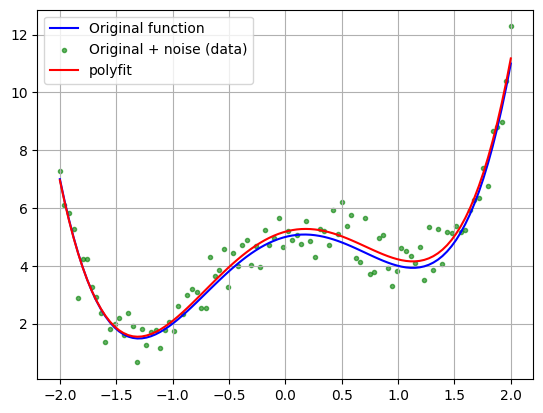

In [4]:
# display
plt.grid()
plt.plot(x, y0, "b", label="Original function")
plt.scatter(x, y, color="g", marker =".", label="Original + noise (data)", alpha=0.6)
plt.plot(x, y_fit, label="polyfit", color="r")
plt.legend()

В останньому таску демонструється підхід до поліноміальної регресії через numpy.polyfit. Демонструється використання SGDRegressor, StandardScaler, роботу з тими ж даними що й у попередньому таску, але з іншими інструментами, гадаю. Порівняння різних методів розв'язання однієї задачі, напевно якось пов'язано з машинним навчанням.

Зроблю порівняння методів з polyfit та sklearn, наскільки є різниця:

Порівняння методів:
numpy+polyfit коефіцієнти: [ 0.991902   -0.97626725  0.50283509]
sklearn коефіцієнти: [ 0.         -0.97626725  0.991902  ] (intercept: 0.5028350882510477)
Різниця тільки в подачі коеф. обидва методи математично еквіваленти


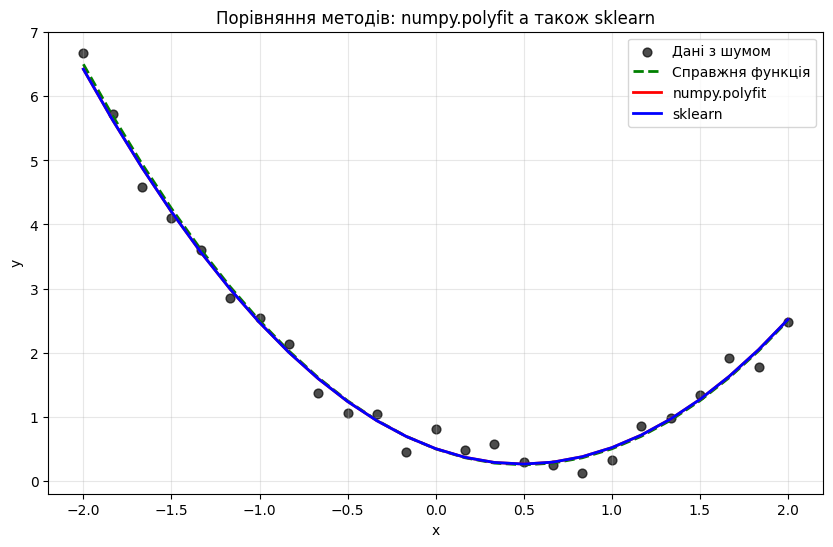

In [15]:

#(Дані ті самі, що вище по таску)
#Метод numpy.polyfit 
coeffs_numpy = np.polyfit(x, y, 2)
y_numpy = np.polyval(coeffs_numpy, x)

#Метод 2 sklearn 
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(x.reshape(-1, 1))
model = LinearRegression()
model.fit(X_poly, y)
y_sklearn = model.predict(X_poly)

# Порівняння на одному графіку
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, color='black', s=40, label='Дані з шумом')
plt.plot(x, y_true, '--', color='green', linewidth=2, label='Справжня функція')
plt.plot(x, y_numpy, 'r-', linewidth=2, label='numpy.polyfit')
plt.plot(x, y_sklearn, 'b-', linewidth=2, label='sklearn')

plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Порівняння методів: numpy.polyfit а також sklearn')
plt.xlabel('x')
plt.ylabel('y')

#Вивід порівняння
print("Порівняння методів:")
print(f"numpy+polyfit коефіцієнти: {coeffs_numpy}")
print(f"sklearn коефіцієнти: {model.coef_} (intercept: {model.intercept_})")
print(f"Різниця тільки в подачі коеф. обидва методи математично еквіваленти")
